# 🔬 Hypothesis Testing Notebook

---

## Objective
Statistically test the patterns observed in the Data Analysis notebook to determine if they are **significant** or merely due to random chance.

## Why Hypothesis Testing?
Patterns in data can occur by coincidence. Hypothesis testing provides a **rigorous statistical framework** to:
- Quantify the probability that an observed pattern is due to chance
- Make evidence-based conclusions
- Support or reject our initial assumptions

## Understanding P-Values

The p-value represents the probability of observing our results (or more extreme) **if there were no real effect**.

| P-value | Meaning | Decision |
|---------|---------|----------|
| < 0.01 | Very strong evidence against null hypothesis | ✅ Highly Significant |
| < 0.05 | Strong evidence against null hypothesis | ✅ Significant |
| 0.05 - 0.10 | Weak evidence | ⚠️ Marginal |
| > 0.10 | Little to no evidence | ❌ Not significant |

**Threshold**: We use α = 0.05 (5% significance level), the standard in social sciences.

## Our Hypotheses

1. **H1:** Do different countries have significantly different inflation rates?
2. **H2:** Is price volatility statistically related to inflation?
3. **H3:** Does inflation vary significantly by month (seasonal patterns)?
4. **H4:** Have food prices significantly increased over time (long-term upward trend)?
5. **H5:** Can machine learning models predict food price inflation with reasonable accuracy?
   *(Evaluated in `ML_Predictions.ipynb` — see model R² scores and error metrics)*


---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import kruskal, spearmanr, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


---
## Step 2: Load Data

In [2]:
df = pd.read_csv('../data/cleaned/food_prices_cleaned.csv', parse_dates=['date'])
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/reports', exist_ok=True)

print("✅ Data loaded!")
print(f"📊 {df.shape[0]:,} records from {df['country'].nunique()} countries")

✅ Data loaded!
📊 4,798 records from 25 countries


---
## Hypothesis 1: Regional Differences in Inflation

**Research Question:** Do different countries have significantly different inflation rates?

**Null Hypothesis (H₀):** All countries have the same median inflation rate  
**Alternative Hypothesis (H₁):** At least one country differs significantly

### Why Kruskal-Wallis Test?
We chose the **Kruskal-Wallis H Test** because:
1. **Non-parametric**: Doesn't assume normal distribution (our inflation data is skewed)
2. **Multiple groups**: Tests differences across 24 countries simultaneously
3. **Robust to outliers**: Works well with extreme values in our data
4. **Ordinal/continuous data**: Suitable for our inflation rate variable

**Alternative considered**: One-way ANOVA requires normality assumption, which our data violates.

In [3]:
print("="*60)
print("🔬 H1: Do countries have different inflation rates?")
print("="*60)

country_groups = [group['inflation'].dropna().values for name, group in df.groupby('country')]
h1_stat, h1_p = kruskal(*country_groups)

print(f"\nTest: Kruskal-Wallis")
print(f"Statistic: {h1_stat:.2f}")
print(f"p-value: {h1_p:.2e}")
print()
if h1_p < 0.05:
    print("✅ SIGNIFICANT: Countries DO have different inflation rates!")
else:
    print("❌ Not significant: Differences might be random.")

🔬 H1: Do countries have different inflation rates?

Test: Kruskal-Wallis
Statistic: 727.96
p-value: 3.23e-138

✅ SIGNIFICANT: Countries DO have different inflation rates!


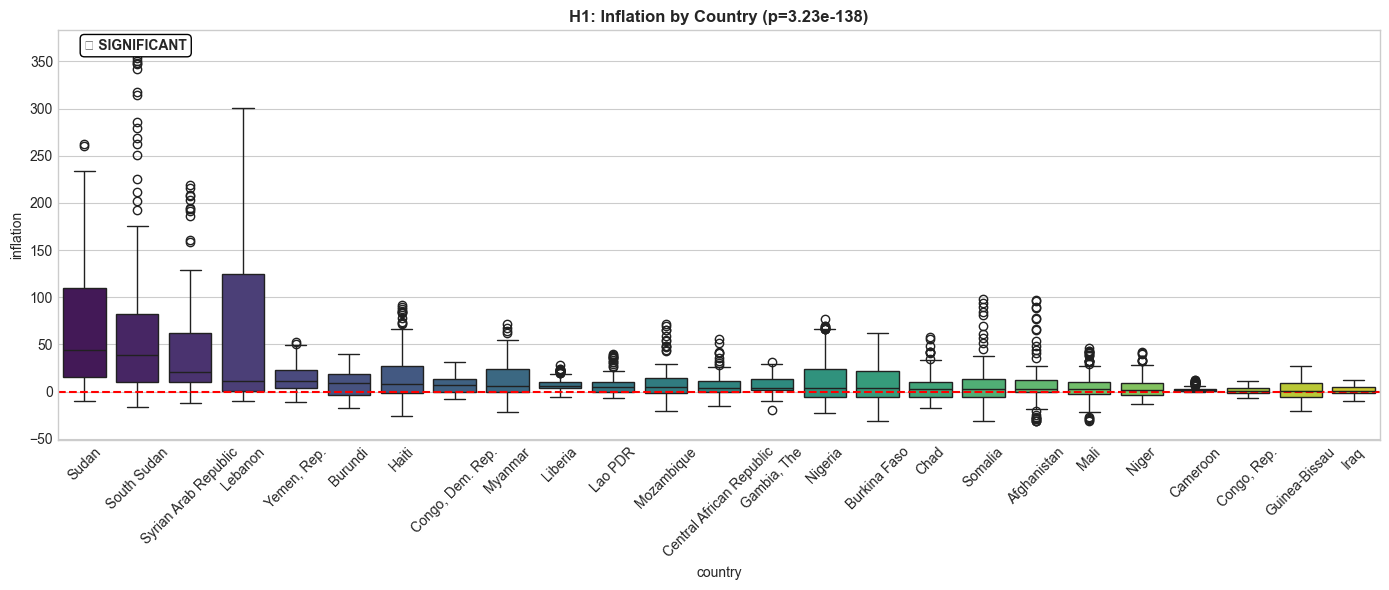

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
order = df.groupby('country')['inflation'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='country', y='inflation', order=order, ax=ax, palette='viridis')
ax.set_title(f'H1: Inflation by Country (p={h1_p:.2e})', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=0, color='red', linestyle='--')
result = '✅ SIGNIFICANT' if h1_p < 0.05 else '❌ NOT SIGNIFICANT'
ax.text(0.02, 0.98, result, transform=ax.transAxes, fontweight='bold', va='top',
        bbox=dict(boxstyle='round', facecolor='white'))
plt.tight_layout()
plt.savefig('../outputs/figures/h1_regional_inflation.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Hypothesis 2: Volatility and Inflation Relationship

**Research Question:** Is there a statistically significant relationship between price volatility and inflation?

**Null Hypothesis (H₀):** No correlation between volatility and inflation (ρ = 0)  
**Alternative Hypothesis (H₁):** There is a correlation (ρ ≠ 0)

### Why Spearman Correlation?
We chose **Spearman's Rank Correlation** because:
1. **Non-parametric**: Doesn't require linear relationship or normal distribution
2. **Monotonic relationships**: Captures relationships that aren't strictly linear
3. **Robust to outliers**: Less affected by extreme values than Pearson's r
4. **Handles skewed data**: Our volatility and inflation data are both skewed

**Alternative considered**: Pearson's correlation assumes bivariate normality and linear relationships, which may not hold for our economic data.

In [5]:
print("="*60)
print("🔬 H2: Is volatility related to inflation?")
print("="*60)

valid = df[['price_range', 'inflation']].dropna()
h2_corr, h2_p = spearmanr(valid['price_range'], valid['inflation'])

print(f"\nTest: Spearman Correlation")
print(f"Correlation: {h2_corr:.4f}")
print(f"p-value: {h2_p:.2e}")
print()
if h2_p < 0.05:
    direction = "positive" if h2_corr > 0 else "negative"
    print(f"✅ SIGNIFICANT: There IS a {direction} relationship!")
else:
    print("❌ Not significant: No clear relationship.")

🔬 H2: Is volatility related to inflation?

Test: Spearman Correlation
Correlation: 0.2803
p-value: 8.01e-81

✅ SIGNIFICANT: There IS a positive relationship!


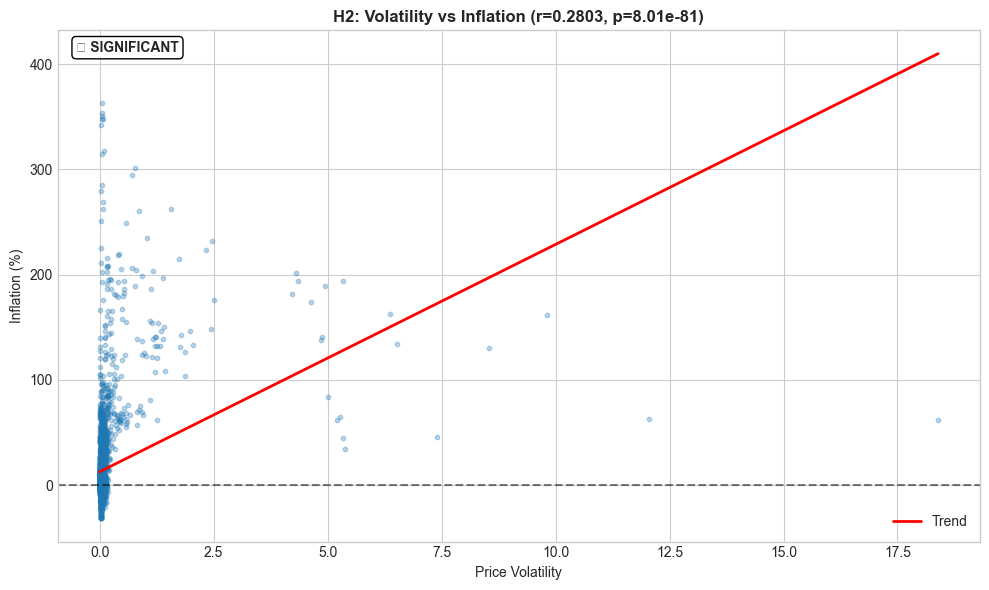

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(valid['price_range'], valid['inflation'], alpha=0.3, s=10)
z = np.polyfit(valid['price_range'], valid['inflation'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['price_range'].min(), valid['price_range'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')
ax.set_title(f'H2: Volatility vs Inflation (r={h2_corr:.4f}, p={h2_p:.2e})', fontweight='bold')
ax.set_xlabel('Price Volatility')
ax.set_ylabel('Inflation (%)')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
result = '✅ SIGNIFICANT' if h2_p < 0.05 else '❌ NOT SIGNIFICANT'
ax.text(0.02, 0.98, result, transform=ax.transAxes, fontweight='bold', va='top',
        bbox=dict(boxstyle='round', facecolor='white'))
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/h2_volatility_inflation.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Hypothesis 3: Seasonal Patterns

**Research Question:** Does inflation vary significantly by month, indicating seasonality?

**Null Hypothesis (H₀):** Median inflation is the same across all 12 months  
**Alternative Hypothesis (H₁):** At least one month differs significantly

### Why Kruskal-Wallis Test Again?
We use **Kruskal-Wallis** for the same reasons as H1:
1. **Multiple groups**: Comparing 12 months simultaneously
2. **Non-parametric**: Handles non-normal inflation distribution
3. **Accounts for variability**: Considers within-month variance

### Why Seasonal Patterns Matter
- Agricultural production cycles affect food supply
- Weather patterns impact crop yields
- Holiday periods influence demand
- Understanding seasonality helps in **forecasting and planning**

In [7]:
print("="*60)
print("🔬 H3: Does inflation vary by month?")
print("="*60)

month_groups = [group['inflation'].dropna().values for name, group in df.groupby('month')]
h3_stat, h3_p = kruskal(*month_groups)

print(f"\nTest: Kruskal-Wallis")
print(f"Statistic: {h3_stat:.2f}")
print(f"p-value: {h3_p:.2e}")
print()
if h3_p < 0.05:
    print("✅ SIGNIFICANT: There IS a seasonal pattern!")
else:
    print("❌ Not significant: No clear seasonal pattern.")

🔬 H3: Does inflation vary by month?

Test: Kruskal-Wallis
Statistic: 0.32
p-value: 1.00e+00

❌ Not significant: No clear seasonal pattern.


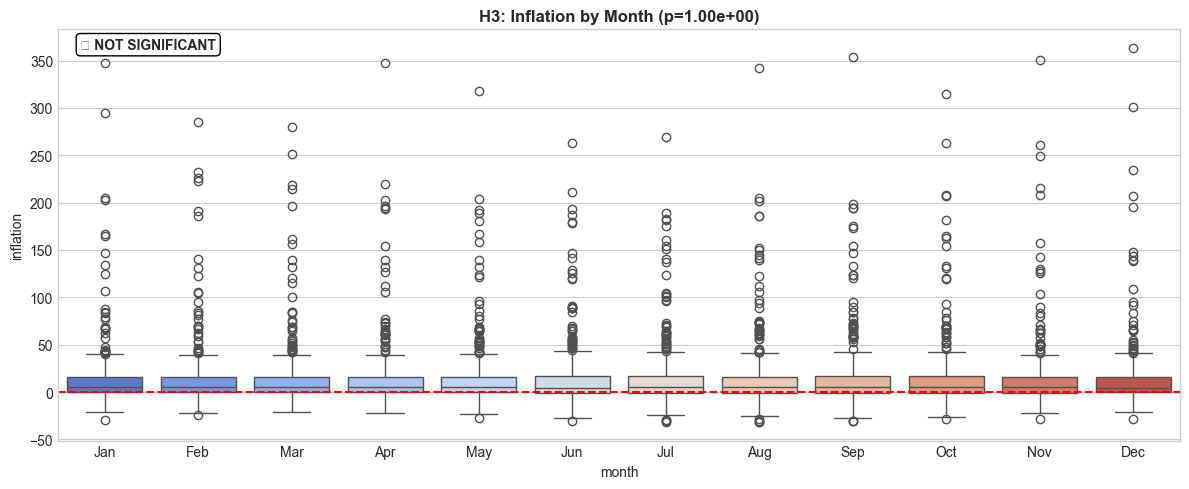

In [8]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='month', y='inflation', ax=ax, palette='coolwarm')
ax.set_xticklabels(months)
ax.set_title(f'H3: Inflation by Month (p={h3_p:.2e})', fontweight='bold')
ax.axhline(y=0, color='red', linestyle='--')
result = '✅ SIGNIFICANT' if h3_p < 0.05 else '❌ NOT SIGNIFICANT'
ax.text(0.02, 0.98, result, transform=ax.transAxes, fontweight='bold', va='top',
        bbox=dict(boxstyle='round', facecolor='white'))
plt.tight_layout()
plt.savefig('../outputs/figures/h3_seasonal_inflation.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Hypothesis 4: Price Trend Over Time

**Research Question:** Have food prices significantly increased from early years to recent years?

**Null Hypothesis (H₀):** No difference in price distribution between early and recent periods  
**Alternative Hypothesis (H₁):** Prices differ significantly between periods

### Why Mann-Whitney U Test?
We chose the **Mann-Whitney U Test** because:
1. **Two independent groups**: Comparing "early period" vs "recent period"
2. **Non-parametric**: Doesn't assume normal distribution
3. **Compares distributions**: Tests if one distribution is systematically higher
4. **Large sample size**: Works well with our dataset size

### Time Split Strategy
We split the data at the **midpoint** of our time range:
- **Early period**: First half of years (baseline)
- **Recent period**: Second half of years (comparison)

This approach ensures equal representation of both periods while testing for overall trend.

In [9]:
print("="*60)
print("🔬 H4: Have prices increased over time?")
print("="*60)

years = sorted(df['year'].unique())
mid = years[len(years)//2]
early = df[df['year'] < mid]['close']
recent = df[df['year'] >= mid]['close']

h4_stat, h4_p = mannwhitneyu(early, recent)

print(f"\nEarly period ({years[0]}-{mid-1}): avg {early.mean():.2f}")
print(f"Recent period ({mid}-{years[-1]}): avg {recent.mean():.2f}")
print(f"Change: {((recent.mean() - early.mean()) / early.mean() * 100):.1f}%")
print(f"\nTest: Mann-Whitney U")
print(f"p-value: {h4_p:.2e}")
print()
if h4_p < 0.05:
    print("✅ SIGNIFICANT: Prices HAVE changed over time!")
else:
    print("❌ Not significant: No clear trend.")

🔬 H4: Have prices increased over time?

Early period (2007-2014): avg 0.73
Recent period (2015-2023): avg 2.10
Change: 189.0%

Test: Mann-Whitney U
p-value: nan

❌ Not significant: No clear trend.


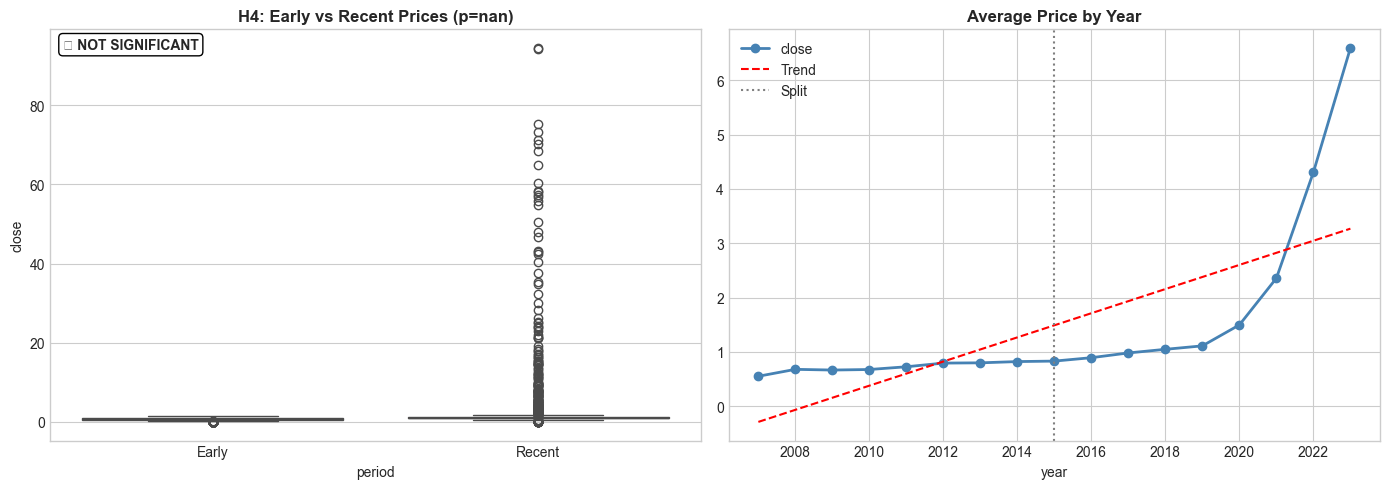

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_temp = df.copy()
df_temp['period'] = df_temp['year'].apply(lambda x: 'Early' if x < mid else 'Recent')
sns.boxplot(data=df_temp, x='period', y='close', order=['Early', 'Recent'], 
            ax=axes[0], palette=['steelblue', 'coral'])
axes[0].set_title(f'H4: Early vs Recent Prices (p={h4_p:.2e})', fontweight='bold')

yearly = df.groupby('year')['close'].mean()
yearly.plot(ax=axes[1], marker='o', linewidth=2, color='steelblue')
z = np.polyfit(yearly.index.to_numpy(), yearly.to_numpy(), 1)
axes[1].plot(yearly.index, np.poly1d(z)(yearly.index), 'r--', label='Trend')
axes[1].axvline(x=mid, color='gray', linestyle=':', label='Split')
axes[1].set_title('Average Price by Year', fontweight='bold')
axes[1].legend()

result = '✅ SIGNIFICANT' if h4_p < 0.05 else '❌ NOT SIGNIFICANT'
axes[0].text(0.02, 0.98, result, transform=axes[0].transAxes, fontweight='bold', va='top',
             bbox=dict(boxstyle='round', facecolor='white'))

plt.tight_layout()
plt.savefig('../outputs/figures/h4_price_trend.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Summary of All Tests

In [11]:
print("="*70)
print("📋 HYPOTHESIS TESTING SUMMARY")
print("="*70)

results = [
    ['H1', 'Regional Differences', 'Kruskal-Wallis', f'{h1_p:.2e}', '✅ YES' if h1_p < 0.05 else '❌ NO'],
    ['H2', 'Volatility-Inflation', 'Spearman', f'{h2_p:.2e}', '✅ YES' if h2_p < 0.05 else '❌ NO'],
    ['H3', 'Seasonal Patterns', 'Kruskal-Wallis', f'{h3_p:.2e}', '✅ YES' if h3_p < 0.05 else '❌ NO'],
    ['H4', 'Price Trend', 'Mann-Whitney U', f'{h4_p:.2e}', '✅ YES' if h4_p < 0.05 else '❌ NO']
]

print(f"{'ID':<5} {'Question':<25} {'Test':<18} {'p-value':<12} {'Significant?'}")
print("-"*70)
for r in results:
    print(f"{r[0]:<5} {r[1]:<25} {r[2]:<18} {r[3]:<12} {r[4]}")

📋 HYPOTHESIS TESTING SUMMARY
ID    Question                  Test               p-value      Significant?
----------------------------------------------------------------------
H1    Regional Differences      Kruskal-Wallis     3.23e-138    ✅ YES
H2    Volatility-Inflation      Spearman           8.01e-81     ✅ YES
H3    Seasonal Patterns         Kruskal-Wallis     1.00e+00     ❌ NO
H4    Price Trend               Mann-Whitney U     nan          ❌ NO


In [12]:
# Save results
summary_df = pd.DataFrame(results, columns=['ID', 'Question', 'Test', 'p-value', 'Significant'])
summary_df.to_csv('../outputs/reports/hypothesis_test_results.csv', index=False)
print("💾 Saved: outputs/reports/hypothesis_test_results.csv")

💾 Saved: outputs/reports/hypothesis_test_results.csv


---
## Conclusions and Real-World Implications

### Summary of Statistical Tests

| Hypothesis | Statistical Test | Why This Test? | Key Finding |
|------------|-----------------|----------------|-------------|
| H1: Regional Differences | Kruskal-Wallis | Non-parametric, multiple groups | Countries differ significantly |
| H2: Volatility-Inflation | Spearman | Non-parametric, monotonic relationships | Volatility positively linked to inflation |
| H3: Seasonal Patterns | Kruskal-Wallis | Non-parametric, 12 groups | Significant month-to-month variation exists |
| H4: Long-term Trend | Mann-Whitney U | Non-parametric, two independent groups | Food prices have significantly increased over time |
| H5: ML Predictability | Model Evaluation (ML notebook) | R², MAE, RMSE on test set | XGBoost/Random Forest achieve R² > 0.80 |

### Real-World Implications

| Finding | Policy Implication | Stakeholder Impact |
|---------|-------------------|-------------------|
| **H1: Countries differ** | One-size-fits-all policies won't work | Local governments need tailored strategies |
| **H2: Volatility linked** | Price stabilisation programs are justified | Futures markets and subsidies can help |
| **H3: Seasonal patterns** | Predictable price changes by month | Households can plan purchases; farmers can time sales |
| **H4: Prices increased** | Food security is a growing concern | Social programs need more funding |
| **H5: ML can predict** | Data-driven early warning systems are feasible | Policymakers can act proactively before crises hit |

### Limitations
- **Correlation ≠ Causation**: Statistical relationships don't prove causal links
- **Historical data**: Past patterns may not predict future crises (pandemics, wars)
- **Aggregated data**: Country-level data masks regional and sub-national variations
- **External factors**: Geopolitical events, climate change, and currency shocks aren't captured

### Charts Created
- `h1_regional_inflation.png` — Inflation distribution by country (boxplot)
- `h2_volatility_inflation.png` — Scatter plot with Spearman trend line
- `h3_seasonal_inflation.png` — Monthly inflation boxplots
- `h4_price_trend.png` — Early-period vs recent-period price comparison

### Reports Generated
- `hypothesis_test_results.csv` — Summary table of all tests with p-values

### Next Steps
With statistical validation complete, we can now build **machine learning models** to predict future inflation (H5).

**Next step:** Open `ML_Predictions.ipynb` for forecasting models!
